for future: get compactness scores for current map

In [12]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob

In [2]:
#print all csv files from the allocation_by_district folder
#note: not in order!
# glob.glob('./allocation_by_district/*.csv')

#alt method for printing all the files...
for files in glob.glob("*.csv"):
    print(files) 

census.csv


In [3]:
# path is a string for the path of the folder we want to check
# path = os.getcwd() + '/allocation_by_county'
path = os.getcwd() + '/allocation_by_district'

#list of all filenames in the path which end in .csv
csv_files = glob.glob(os.path.join(path, "*.csv")) 
num_files = len(csv_files) #count of all files

# file_name = './allocation_by_county/seed_{}_by_county.csv'
file_name = './allocation_by_district/seed_{}_by_district.csv'
df_list = []
for i in range(num_files):
   iter_number=str(i).rjust(3,'0')
   df_list.append(pd.read_csv(file_name.format(iter_number)))


In [4]:
df=pd.read_csv('./allocation_by_district/seed_000_by_district.csv')
df.head()

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((325806.7526410533 4617405.525501856,...",790938,372444.169336,4.728577e+06,1,5.205925e+10,1.520782e+06,0.282862,196808.630282,0.427819
1,POLYGON ((299099.54163576674 4529226.381343519...,805940,327097.814266,4.596430e+06,2,2.053676e+10,1.019181e+06,0.248450,134906.014493,0.359186
2,"POLYGON ((530528.6206347387 4493399.353433513,...",788707,524544.364344,4.570685e+06,3,4.652257e+10,1.297989e+06,0.347002,202190.998226,0.362235
3,POLYGON ((605837.8838751405 4635240.0353934495...,804784,615374.058472,4.721685e+06,4,2.657951e+10,9.930376e+05,0.338708,159407.355618,0.332951


In [5]:
full_nestedlist=[]
for j in range(num_files):
    temp_df = df_list[j]
    list_for_j=[j, temp_df.loc[0,'Reock'],temp_df.loc[1,'Reock'],temp_df.loc[2,'Reock'],temp_df.loc[3,'Reock'],
                temp_df['Reock'].min(),temp_df['Reock'].max(),temp_df['Reock'].mean(),
    temp_df.loc[0,'PolsbyPopper'],temp_df.loc[1,'PolsbyPopper'],
    temp_df.loc[2,'PolsbyPopper'],temp_df.loc[3,'PolsbyPopper'],
                temp_df['PolsbyPopper'].min(),temp_df['PolsbyPopper'].max(),temp_df['PolsbyPopper'].mean(),
    temp_df['population'].min(),temp_df['population'].max()
    ]
    full_nestedlist.append(list_for_j)

# full_nestedlist


In [6]:
column_dict=[
    'seed',
    'Reock_d1',
    'Reock_d2',
    'Reock_d3',
    'Reock_d4',
    'Reock_min',
    'Reock_max',
    'Reock_mean',
    'PP_d1',
    'PP_d2',
    'PP_d3',
    'PP_d4',
    'PP_min',
    'PP_max',
    'PP_mean',
    'min_pop',
    'max_pop']

In [7]:
compactness_data_df = pd.DataFrame(full_nestedlist,columns=column_dict)

In [8]:
column_dict_analysis=[
    'seed',
    'Reock_min',
    'Reock_max',
    'Reock_mean',
    'PP_min',
    'PP_max',
    'PP_mean',
    'min_pop',
    'max_pop']

In [ ]:
compactness_analysis_df = compactness_data_df[column_dict_analysis]
compactness_analysis_df

,seed,Reock_min,Reock_max,Reock_mean,PP_min,PP_max,PP_mean,min_pop,max_pop
0,0,0.332951,0.427819,0.370548,0.248450,0.347002,0.304255,788707,805940
1,1,0.448682,0.567162,0.508731,0.338438,0.498848,0.435282,791513,802747
2,2,0.361399,0.510667,0.447749,0.258152,0.448787,0.374006,357891,1259047
3,3,0.428981,0.562479,0.490348,0.294441,0.384121,0.339815,791071,804852
4,4,0.334623,0.470270,0.417341,0.279986,0.503789,0.401802,787989,806571
...,...,...,...,...,...,...,...,...,...
255,255,0.377538,0.521105,0.442242,0.299119,0.496623,0.403687,786876,808747
256,256,0.401156,0.501474,0.445208,0.355950,0.491336,0.410126,787180,804198
257,257,0.347251,0.471203,0.416687,0.330434,0.417375,0.367020,793050,803696
258,258,0.448234,0.609830,0.514783,0.437062,0.480777,0.469487,781197,816294


In [ ]:
#show all rows instead of first 5/last 5
# pd.set_option('display.max_rows', None)
# compactness_analysis_df

#reset max_rows:
# pd.reset_option(“max_rows”)

In [14]:
enacted_map=pd.read_csv('enacted_map.csv')
enacted_map

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((597046.3063824802 4495965.241673183,...",797584,655223.617473,4.626175e+06,1,2.847289e+10,1.120709e+06,0.284876,160047.768111,0.353820
1,"POLYGON ((558251.4820985557 4634182.10198691, ...",797589,631594.469070,4.793646e+06,2,3.361224e+10,1.004718e+06,0.418426,141576.968905,0.533780
2,POLYGON ((413996.78923838487 4491953.713269984...,797551,376909.476792,4.576509e+06,3,2.782373e+10,9.971415e+05,0.351651,144824.951242,0.422259
3,"POLYGON ((299084.9524567265 4528678.815421122,...",797645,341387.505752,4.616499e+06,4,5.578923e+10,1.595846e+06,0.275282,191597.504183,0.483750


In [18]:
enacted_Reock_min = enacted_map['Reock'].min()
enacted_Reock_mean = enacted_map['Reock'].mean()
enacted_PP_min = enacted_map['PolsbyPopper'].min()
enacted_PP_mean = enacted_map['PolsbyPopper'].mean()

<Axes: xlabel='Reock_min'>

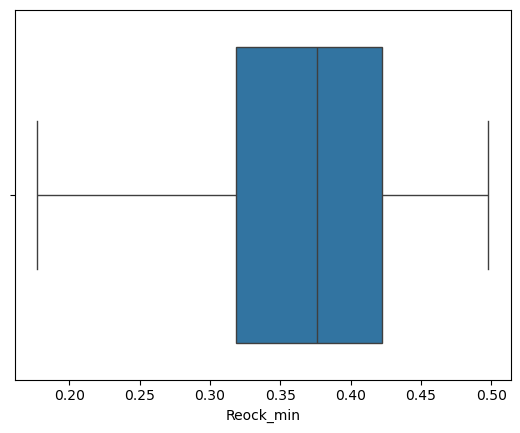

In [28]:
sns.boxplot(data=compactness_analysis_df, x='Reock_min', zorder=1)
# plt.boxplot(compactness_analysis_df['Reock_min'], zorder=1)
# sns.scatterplot(x=enacted_Reock_min, zorder=2)


- Graph Reock min/mean, Polsby-Popper min/mean for all simulated maps.
- Plot points for Reock/Polsby-Popper min/mean for both the enacted map and 2020 alternate